<pre style="font-size: 15px; line-height: 1.2;">
---
course_code: 02BMSBI24365
course_title: AI and ML in Bioinformatics
institution: Garden City University (GCU)
program: M.Sc. Bioinformatics (Semester III)
unit: Unit 1 — Foundations of Machine Learning for Bioinformatics
submodule: 1.1 Introduction to Machine Learning in Bioinformatics
document_type: Guided Lecture Notebook
ai_tier: Full AI (Learning Aid)
---
</pre>

# 🧬 Introduction to Machine Learning in Bioinformatics

---

**Overview of ML; types of ML (supervised, unsupervised)**

This introduction teaches the machine-learning workflow before we deep dive into individual concepts. We use patient glucose levels through the foundations, classifying diabetes status.

## Session map

1. What is Machine Learning? (Traditional vs ML) (10 min)
2. The 4 Key Steps in the Machine Learning Process (5 min)
3. Dataset Samples, Features, Targets, and Train/Test Splits (10 min)
4. The Machine Learning Landscape (5 min)
5. Regression: Predicting Glucose Levels (25 min)
6. Classification: Predicting a Category (Diabetes Diagnosis) (25 min)

## Setup

Everything in this notebook is fictional and runs locally. If this cell fails, install `scikit-learn` in the active Python environment.

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.model_selection import train_test_split

print("Setup complete: local scikit-learn tools are ready.")

Setup complete: local scikit-learn tools are ready.


---
## What Is Machine Learning?

Read the definitions below. Which ones describe machine learning, and which ones describe something else?

1. A field of computer science where algorithms find patterns in data and build mathematical models to make predictions or decisions without explicit human programming.
2. A branch of computer science and statistics focused on building algorithms that can predict outcomes or classify information accurately.
3. A subset of artificial intelligence that automates analytical model building, allowing software systems to adapt and learn new behaviours as they ingest new data.
4. Any software program that follows a fixed, step-by-step flowchart or hardcoded logic rules written by a programmer to automate a task.
5. A type of database technology that memorises every piece of data it receives so it can instantly recall that exact information later.

## Traditional Programming vs. Machine Learning

**Traditional programming:** Humans explicitly define the rules that transform an input into an output.

**Machine learning:** Instead of explicitly writing every rule, we provide data and expected outputs. The algorithm learns patterns from the data and uses the learned model to make predictions on new inputs.

### In short

- **Traditional programming:** Humans write the rules → program produces an output.
- **Machine learning:** Data teaches the rules → model produces an output.

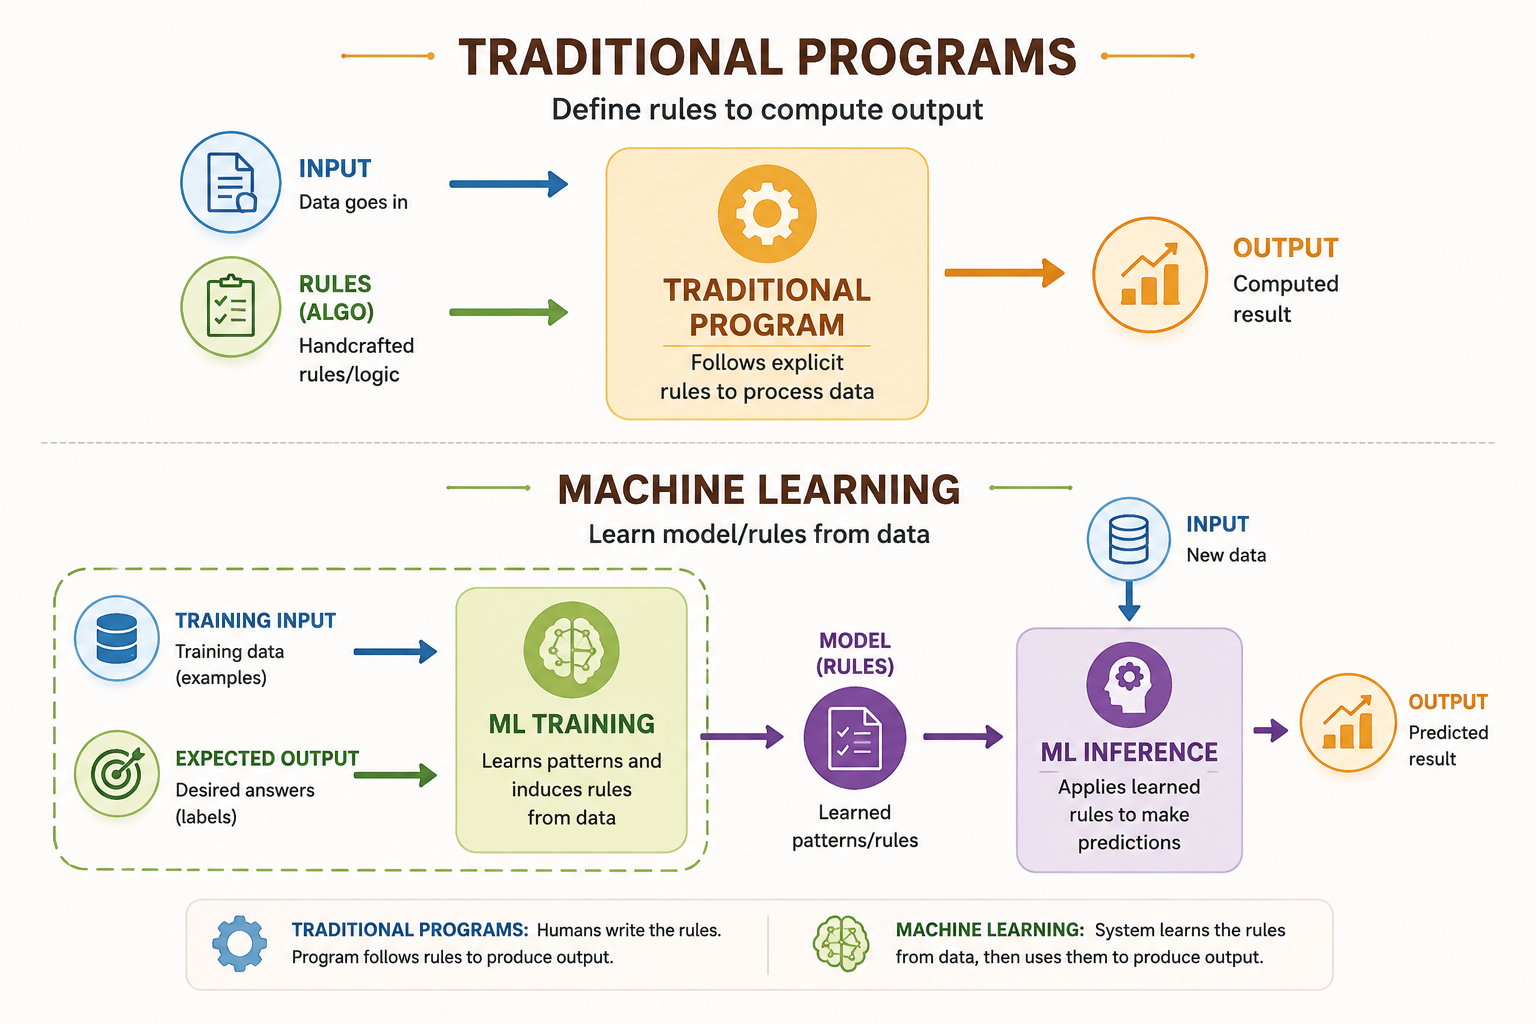

## Traditional Programming Example

We explicitly define the rule that converts fasting time into predicted glucose levels.

Let’s take a simple example to understand this. Here, we have a dataset containing patients’ fasting hours per day and their corresponding glucose levels. 

In traditional programming, we explicitly define a rule to calculate the expected glucose levels based on fasting hours. For example, 
we can define the rule as Glucose Levels = 170 - 5 × Fasting Hours per day. The program then applies this rule to each patient’s fasting hours and produces the predicted glucose levels. 
The important point is that the rule is defined by us; the program does not learn it from the data.

In [20]:
patient_data = pd.DataFrame({
    'fasting_hours': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'glucose_levels': [160, 155, 145, 140, 138, 130, 125, 120, 115, 110, 105, 100, 95, 90]
})

def written_rule(hours):
    return 170 - 5 * hours


print("Written rule: predicted glucose levels = 170 - 5 × fasting hours")

patient_data.assign(rule_prediction=patient_data.fasting_hours.map(written_rule)).head(8)

Written rule: predicted glucose levels = 170 - 5 × fasting hours


,fasting_hours,glucose_levels,rule_prediction
0,2,160,160
1,3,155,155
2,4,145,150
3,5,140,145
4,6,138,140
5,7,130,135
6,8,125,130
7,9,120,125


- The rule assumes that glucose levels decrease by 5 for every additional fasting hour.
- Real data may not follow this pattern; a patient may fast longer but have higher glucose due to insulin resistance.
- The written rule cannot automatically adapt because it was manually defined.
- This leads to a key question: can a system learn the relationship from data instead?

**That naturally leads into Machine Learning.**

---
## The 4 Key Steps in the Machine Learning Process

Before diving into the code, it is important to understand that every machine learning pipeline generally follows four core steps:

1. **Dataset Preparation:** Cleaning the data, organizing features and targets, and splitting it into training and testing sets.
2. **Model Selection:** Choosing the right algorithm for the job (e.g., Linear Regression for continuous numbers, Random Forest for classification).
3. **Model Training:** Feeding the training data into the chosen model so it can learn the underlying biological patterns.
4. **Model Testing:** Evaluating the trained model on unseen testing data to verify its accuracy and reliability.

---
## Dataset Samples, Features, Targets, and Train/Test Splits

Now, let’s make these predictions using a **machine-learning approach** instead. Before building the model, introduce the concepts used throughout this example: **samples, features, targets, and training/testing data**.

In our dataset, each **row represents one sample**, in this case, one patient and their fasting-and-glucose information.
- A **feature** is information given to the model to help it make a prediction. Here, **fasting hours** is the feature.
- A **target** is what we want the model to predict. Here, the target is the patient’s **glucose levels**.
- We split the dataset into two parts: **training data** and **test data**.
- **training data** is used by the model to learn the relationship between fasting hours and glucose levels. 
- **test data** is kept aside and used later to check how well the model performs on data it has not seen during training.

<br>

So, in this example:
* **Samples:** Individual patients/rows in our dataset
* **Feature:** Fasting hours
* **Target:** Glucose Levels
* **Training set:** Data used to learn the relationship
* **Test set:** Data used to evaluate the learned model


In [21]:
print("Step 1 · Prepare the dataset")

X = patient_data[['fasting_hours']]
y_glucose = patient_data['glucose_levels']
X_train, X_test, y_train, y_test = train_test_split(
    X, y_glucose, test_size=0.30, random_state=42
)

print("Dataset summary")
print(f"  Training samples:  {len(X_train)}")
print(f"  Test samples:      {len(X_test)}")
print(f"  Input feature:     {list(X.columns)}")
print(f"  Prediction target: {y_glucose.name}")

Step 1 · Prepare the dataset
Dataset summary
  Training samples:  9
  Test samples:      5
  Input feature:     ['fasting_hours']
  Prediction target: glucose_levels


---
## The Machine Learning Landscape

Before we build our first model, let's look at how Machine Learning is categorized. The two main branches are **Supervised** and **Unsupervised** learning. 

```mermaid
graph TD
    ML["Machine Learning"] --> SL["Supervised Learning (Data has labels/targets)"]
    ML --> UL["Unsupervised Learning (Data has no labels)"]
    SL --> REG["Regression (Predicting a continuous number, e.g., Glucose Level)"]
    SL --> CLS["Classification (Predicting a category, e.g., Diabetes Yes/No)"]
    UL --> CLU["Clustering (Finding hidden groups, e.g., Discovering cancer subtypes)"]
    UL --> DIM["Dimensionality Reduction (Simplifying complex data, e.g., PCA on genes)"]
```

In this precap session, we will focus exclusively on **Supervised Learning** (Regression and Classification).

---
## Regression: Predicting Glucose Levels

Now that we have our training and test data ready, let’s look at **regression**.

Regression is a machine learning technique used when we want to **predict a numerical value**.

In our example, we want to predict a patient’s **glucose levels** based on the number of **hours they fast**.

So, we have:

* **Input (feature):** Fasting hours
* **Output (target):** Glucose Levels
* **Problem type:** Regression, because glucose levels are numerical values

The machine learning model looks at the training data and learns the relationship between **fasting hours and glucose levels**.

Unlike our earlier example, where **we manually wrote the rule** `Glucose Levels = 170 - 5 × Fasting Hours`, here we do not explicitly tell the model what the rule should be.

Instead, we give the model the training examples:

> Fasting hours → Glucose Levels

The model learns a relationship from these examples and uses that learned relationship to make predictions for new patients.

For example, after training, if we give the model a patient who fasted for **7.5 hours**, the model can estimate the patient’s expected glucose levels.

This is the key idea of **regression**:
**learn a relationship from existing data and use it to predict a numerical value for new data.**

For our example, we’ll use **linear regression**, which tries to find the best-fitting straight line through the observed data points.


In [22]:
print("Step 2 · Create the regression model")
glucose_model = LinearRegression()

print("Step 3 · Train the regression model")
glucose_model.fit(X_train, y_train)

print("Step 4 · Test the regression model")
test_mark_predictions = glucose_model.predict(X_test)
regression_mae = mean_absolute_error(y_test, test_mark_predictions)
print(f"Mean absolute error: {regression_mae:.2f} glucose levels")


results = X_test.copy()
results['actual_glucose'] = y_test
results['predicted_glucose'] = test_mark_predictions.round(1)
results['predicted_glucose'] = results['predicted_glucose'].apply(lambda x: 0 if x < 0 else x)
results.sort_values('fasting_hours')

Step 2 · Create the regression model
Step 3 · Train the regression model
Step 4 · Test the regression model
Mean absolute error: 0.97 glucose levels


,fasting_hours,actual_glucose,predicted_glucose
0,2,160,157.4
5,7,130,131.1
9,11,110,110.1
11,13,100,99.6
12,14,95,94.4


In [23]:
print(f"Learned slope:     {glucose_model.coef_[0]:.2f}")
print(f"Learned intercept: {glucose_model.intercept_:.2f}")

print(f"Learned rule: predicted glucose levels ≈ {glucose_model.intercept_:.2f} {glucose_model.coef_[0]:.2f} × fasting hours")

Learned slope:     -5.25
Learned intercept: 167.89
Learned rule: predicted glucose levels ≈ 167.89 -5.25 × fasting hours


### Compare the learned rule

The equation learned by the model is close to, but not exactly the same as, the rule we manually defined earlier.

### Visualizing the Simple Linear Regression

To show that this is just **Simple Linear Regression**, let's plot our original data points (fasting hours vs glucose levels) and overlay the 'line of best fit' that our model just learned!

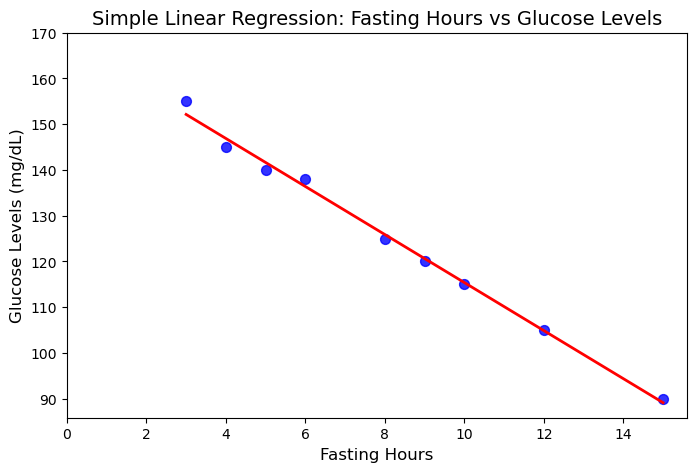

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# We use seaborn's regplot to plot the data points and the regression line
sns.regplot( x=X_train, y=y_train, ci=None, 
            scatter_kws={'color': 'blue', 's': 50}, line_kws={'color': 'red', 'linewidth': 2})

plt.title('Simple Linear Regression: Fasting Hours vs Glucose Levels', fontsize=14)
plt.xlabel('Fasting Hours', fontsize=12)
plt.ylabel('Glucose Levels (mg/dL)', fontsize=12)

plt.xlim(left=0) 
plt.ylim(top=170)

plt.show()

> **⚠️ Important Note on the Regression Line and the Y-Intercept (`b`)**
> 
> Looking at the plot above, you might naturally assume the point where the red line hits the left boundary of the chart is the mathematical "y-intercept" (where $X=0$). **It is not!** 
> 
> By default, Python automatically "zooms in" to fit the data, meaning the X-axis on this plot starts at the lowest fasting hour (e.g., $X=8$ hours), rather than $X=0$. The true analytical y-intercept calculated by the model exists far off to the left of this visible box. This visual vs. mathematical scaling illusion is a common pitfall in data visualization!

## Classification: predicting a category

We derive a `diabetes` diagnosis label from the same glucose dataset. Classification chooses between categories rather than predicting a continuous number.

In [25]:
print("Step 1 · Prepare the classification dataset")

patient_data['diabetes'] = (patient_data['glucose_levels'] >= 126).astype(int)

X_class = patient_data[["glucose_levels"]]
y_diabetes = patient_data["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_diabetes, test_size=0.30, random_state=42, stratify=y_diabetes
)
print(patient_data[["glucose_levels", "diabetes"]].head())


print("Step 2 · Create the classification model")
diabetes_model = LogisticRegression()

print("Step 3 · Train the classification model")
diabetes_model.fit(X_train, y_train)


print("Step 4 · Test the classification model")
diabetes_prediction = diabetes_model.predict(X_test)
classification_accuracy = accuracy_score(y_test, diabetes_prediction)
print(f"Classification accuracy: {classification_accuracy:.0%}")

Step 1 · Prepare the classification dataset
   glucose_levels  diabetes
0             160         1
1             155         1
2             145         1
3             140         1
4             138         1
Step 2 · Create the classification model
Step 3 · Train the classification model
Step 4 · Test the classification model
Classification accuracy: 100%


In [26]:
results_status = X_test.copy()
results_status['actual_diabetes'] = y_test
results_status['predicted_diabetes'] = diabetes_prediction
results_status.sort_values('glucose_levels')

,glucose_levels,actual_diabetes,predicted_diabetes
12,95,0,0
10,105,0,0
9,110,0,0
2,145,1,1
1,155,1,1
